# Batched Hamming weight phasing

In this notebook, we'll go over the circuit for a batched version of Hamming weight phasing (HWP). For more details on the "regular" Hamming weight phasing, check out its tutorial! In batched HWP, instead of treating an entire "tower" of rotations (of the same angle) with one HWP circuit, you can divide up the tower into $k$ batches. In our implementation, $k$ is restricted to be a power of 2 but this doesn't need to be the case in principle.

Let us look at the circuit we'd like to implement:

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from psiqworkbench.utils.rotation_utils import handle_rotation

import psiqworkbench.qubricks as qbk
from psiqworkbench import QPU, Qubits
from psiqworkbench.utils.numpy_utils import fidelity
from psiqworkbench.resource_estimation.witness_counter.witness_metrics_functions import get_baseline_costs_from_witness
from workbench_algorithms import (
    ComputeHammingWeightGroupOfThrees,
    ComputeHammingWeightNaive,
    PowerOfTwoBatchedHammingWeightPhasing,
)

In [3]:
# Angle of the set of rotations we'd like to implement
true_angle = 167.872
bits_of_precision = 5

# In practice, we'll support a finite bit precision
angle = handle_rotation(angle=true_angle, bits_of_precision=bits_of_precision)
print(f'Truncated angle: {angle}')

# Total number of target qubits in the rotation tower
number_of_target_qubits = 6

Truncated angle: 168.75


In [4]:
# Allocate enough qubits to the QPU for Hamming weight computation and adder
n_qubits = number_of_target_qubits + 10

We first look at the original tower of rotations:

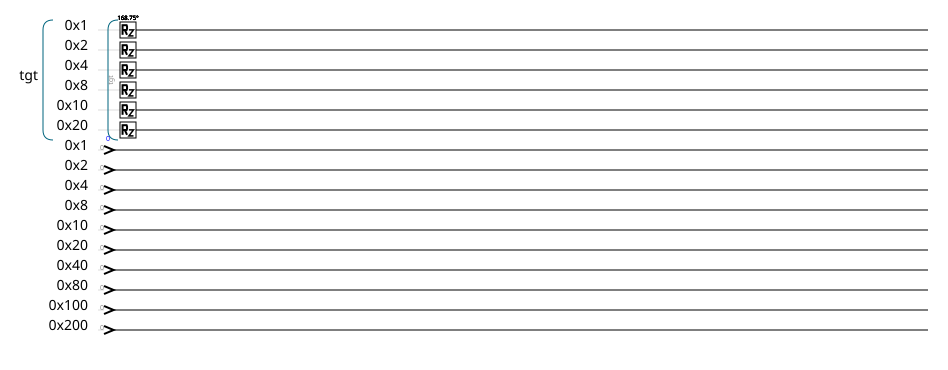

In [5]:
# Visualize the tower of rotations
qc = QPU()
qc.reset(n_qubits)

tgt = Qubits(number_of_target_qubits, 'tgt', qc)

# Set a random initial state
qc.set_random()
qc.write(0, ~(tgt).mask())
init_state = qc.pull_state()

tgt.rz(angle)

# for easier visualization
qc.nop(repeat=40)

# save the final state
wf_ref = qc.pull_state()

qc.draw()

We then apply a single round of Hamming weight phasing on the entire tower of rotations (i.e. a single batch). Because we want to compare the final state vectors, we choose naive versions of computing the Hamming weight.

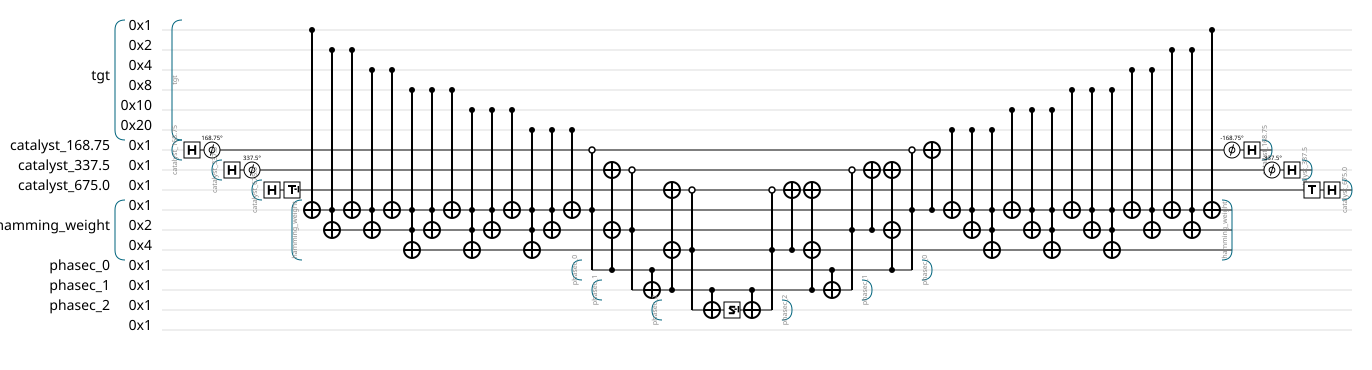

In [6]:
qc = QPU(pre_filters=['>>witness>>'])
qc.reset(n_qubits)

tgt = Qubits(number_of_target_qubits, 'tgt', qc)

# push the same initial state
qc.push_state(init_state)

hamming_weight_qubrick = ComputeHammingWeightNaive(adder=qbk.NaiveAdd())
batched_hamming_weight_qubrick = PowerOfTwoBatchedHammingWeightPhasing(
    hamming_weight_qubrick,
    n_hwp_batches=1  # one batch
)
batched_hamming_weight_qubrick.compute(angle, tgt, ctrl=0)

# Release after to get rotation counts
# since in practice, this is a one-time cost
qc.release_all_rotation_catalyst_qubits()
wf_hwp = qc.pull_state()

qc.draw()

In [7]:
qubits_single_batch_hwp = qc.utilized_qubit_highwater

What if we want to save on some number of qubits? We can divide up the original tower of rotations in $k$ batches via setting `n_hwp_batches` to a power-of-2 number in `PowerOfTwoBatchedHammingWeightPhasing`. Here, we look at two batches:

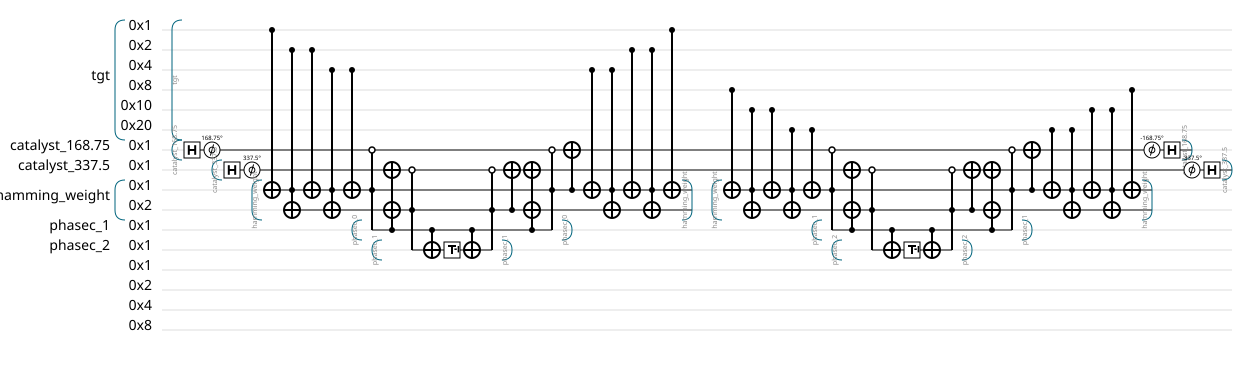

In [8]:
qc = QPU(pre_filters=['>>witness>>'])
qc.reset(n_qubits)

tgt = Qubits(number_of_target_qubits, 'tgt', qc)

qc.push_state(init_state)

hamming_weight_qubrick = ComputeHammingWeightNaive(adder=qbk.NaiveAdd())
batched_hamming_weight_qubrick = PowerOfTwoBatchedHammingWeightPhasing(
    hamming_weight_qubrick,
    n_hwp_batches=2
)
batched_hamming_weight_qubrick.compute(angle, tgt, ctrl=0)

# Release after to get rotation counts
# since in practice, this is a one-time cost
qc.release_all_rotation_catalyst_qubits()
wf_hwp_batched = qc.pull_state()

qc.draw()

In [9]:
qubits_two_batch_hwp = qc.utilized_qubit_highwater

In [10]:
# Check that all three circuits output the same output state up to a global phase
assert np.isclose(fidelity(wf_ref, wf_hwp), 1)
assert np.isclose(fidelity(wf_ref, wf_hwp_batched), 1)

In [11]:
# Check that the single-batch HWP uses more qubits
assert qubits_two_batch_hwp < qubits_single_batch_hwp

Now that we've verified the states, let's look at larger circuits with larger towers of rotations and check the qubit counts!

In [12]:
# Total number of target qubits in the rotation tower
number_of_target_qubits = 36

n_qubits = number_of_target_qubits + 80

Again, we apply one batch of HWP:

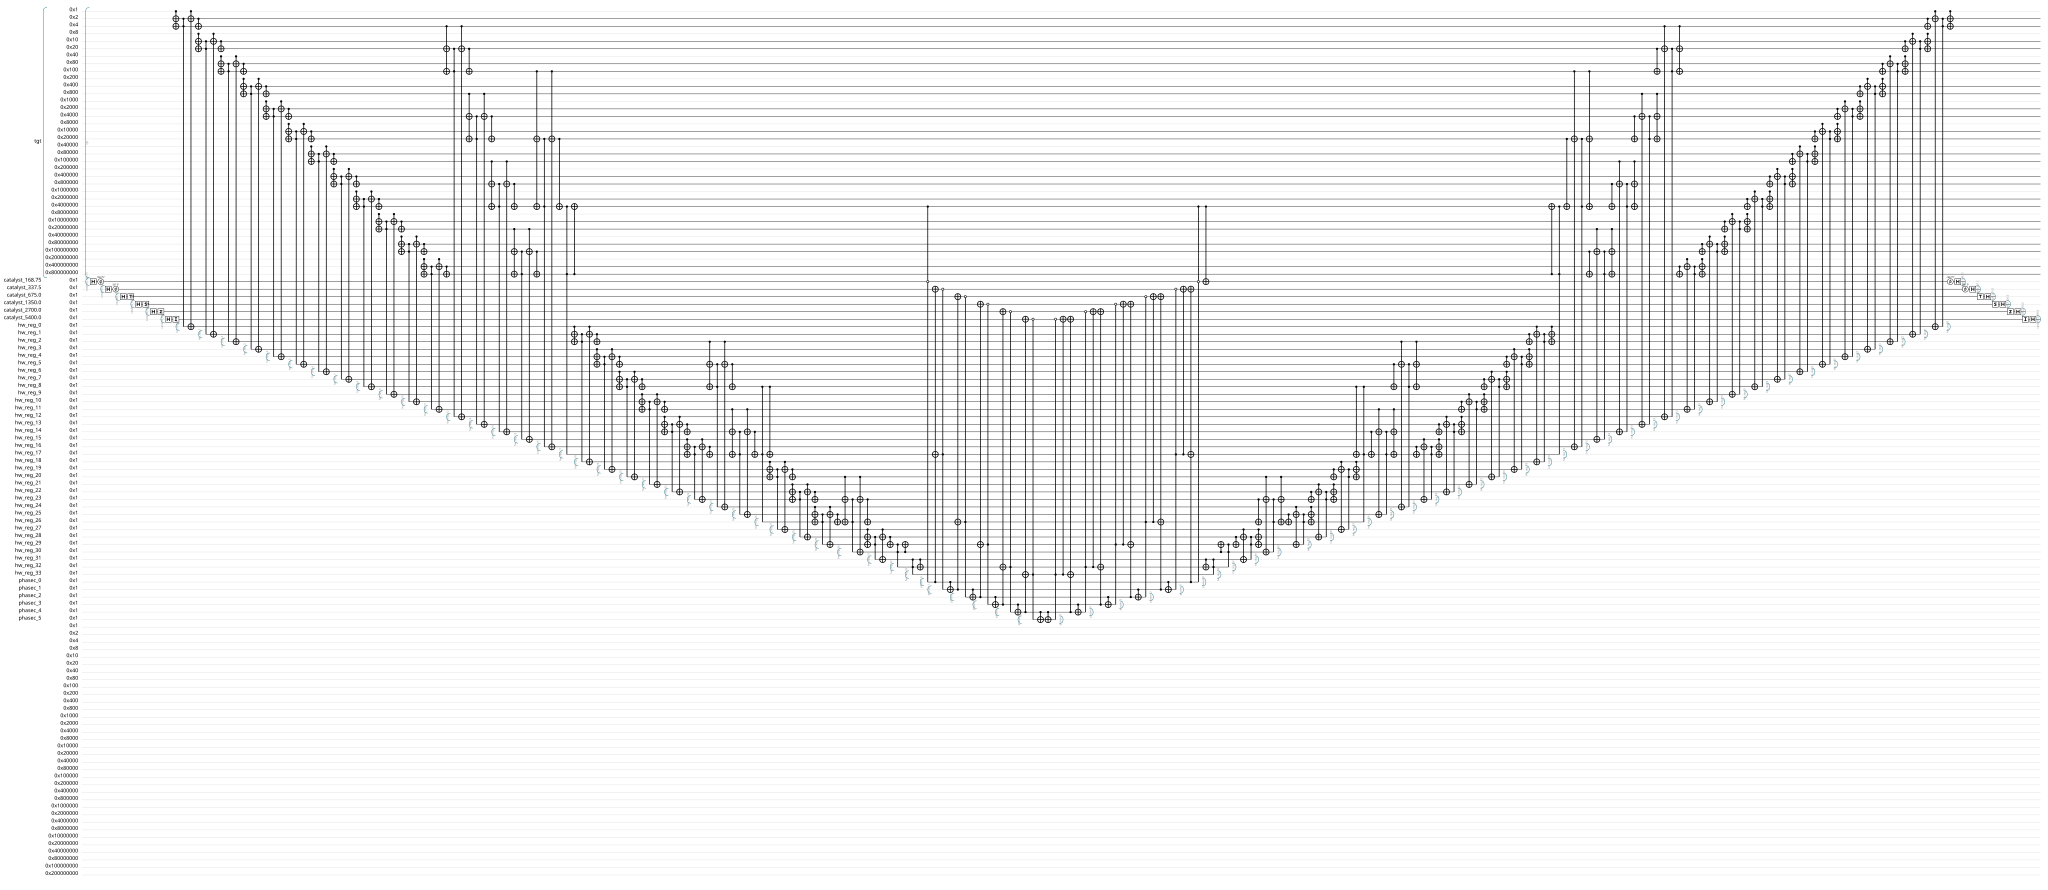

In [13]:
qc = QPU(pre_filters=['>>witness>>'], filters=['>>buffer>>'])
qc.reset(n_qubits)

tgt = Qubits(number_of_target_qubits, 'tgt', qc)

hamming_weight_qubrick = ComputeHammingWeightGroupOfThrees()
batched_hamming_weight_qubrick = PowerOfTwoBatchedHammingWeightPhasing(
    hamming_weight_qubrick,
    n_hwp_batches=1  # one batch
)
batched_hamming_weight_qubrick.compute(angle, tgt, ctrl=0)

metrics_hwp = get_baseline_costs_from_witness(qc.witness)
n_catalyst_rotations_hwp = len(qc._rotation_catalyst_qubits.keys())
metrics_hwp['n_catalyst_rots'] = n_catalyst_rotations_hwp

# Release after to get rotation counts
# since in practice, this is a one-time cost
qc.release_all_rotation_catalyst_qubits()

qbit_count_single_hwp = qc.utilized_qubit_highwater

qc.draw()

... and apply HWP with 8 batches:

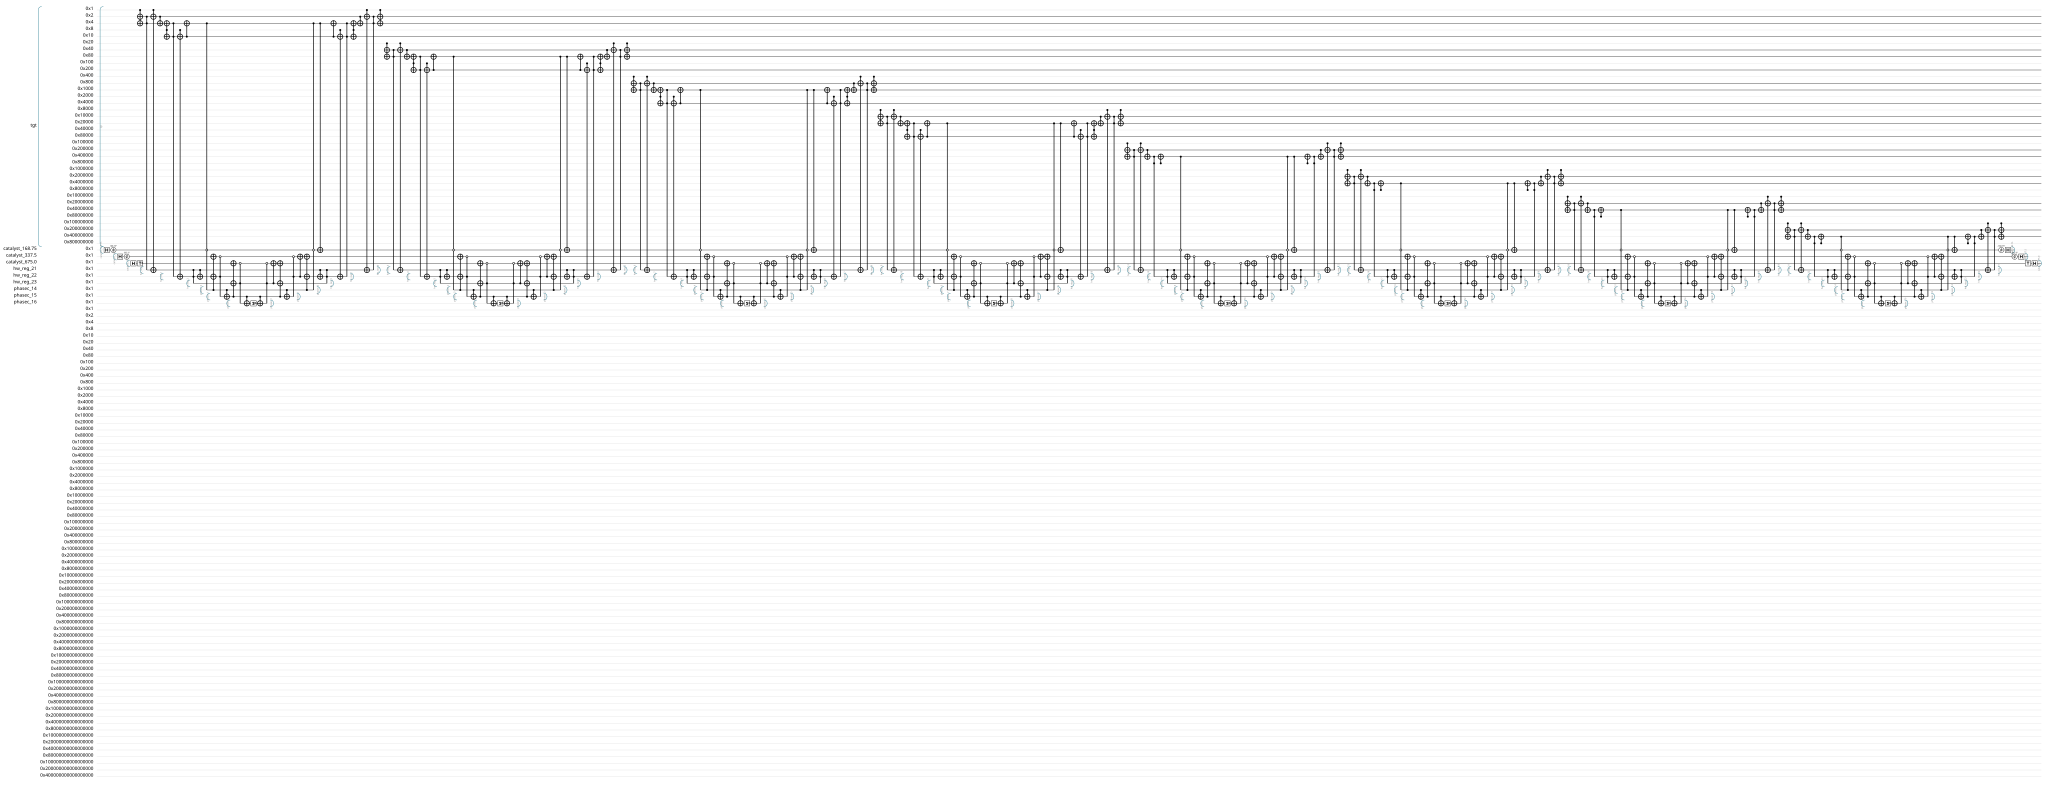

In [14]:
qc = QPU(pre_filters=['>>witness>>'], filters=['>>buffer>>'])
qc.reset(n_qubits)

tgt = Qubits(number_of_target_qubits, 'tgt', qc)

hamming_weight_qubrick = ComputeHammingWeightGroupOfThrees()
batched_hamming_weight_qubrick = PowerOfTwoBatchedHammingWeightPhasing(
    hamming_weight_qubrick,
    n_hwp_batches=2**3  # eight batches
)
batched_hamming_weight_qubrick.compute(angle, tgt, ctrl=0)

metrics_hwp_batched = get_baseline_costs_from_witness(qc.witness)
n_catalyst_rotations_hwp_batched = len(qc._rotation_catalyst_qubits.keys())
metrics_hwp_batched['n_catalyst_rots'] = n_catalyst_rotations_hwp_batched


# Release after to get rotation counts
# since in practice, this is a one-time cost
qc.release_all_rotation_catalyst_qubits()

qbit_count_eight_hwp = qc.utilized_qubit_highwater

qc.draw()

In [15]:
print(qbit_count_single_hwp)
print(qbit_count_eight_hwp)
assert qbit_count_single_hwp > qbit_count_eight_hwp

82
45


In [16]:
print(metrics_hwp['aggregated_toff_count'])
print(metrics_hwp_batched['aggregated_toff_count'])
assert metrics_hwp_batched['aggregated_toff_count'] > metrics_hwp['aggregated_toff_count']

40
48


We see that the batched HWP uses fewer qubits but a few more Toffolis. This is another space-time tradeoff one could use. For early fault-tolerant quantum computers, when we're limited by the number of logical qubits, using batched HWP may help fit your computation onto the device.